--- Début de l'analyse du taux de change EUR/USD ---
Récupération des données pour EUR/USD=X du 2025-05-24 au 2025-06-23...
Données récupérées avec succès (21 jours).
Données enregistrées dans taux_change_eur_usd_simple.csv

Chargement des données depuis taux_change_eur_usd_simple.csv...
Données chargées avec succès.

--- Extrait des Données Brutes ---
| Date                      |    Open |    High |     Low |   Close |   Volume |   Dividends |   Stock Splits |
|:--------------------------|--------:|--------:|--------:|--------:|---------:|------------:|---------------:|
| 2025-05-26 00:00:00+01:00 | 1.13728 | 1.14189 | 1.13693 | 1.13728 |        0 |           0 |              0 |
| 2025-05-27 00:00:00+01:00 | 1.13885 | 1.1409  | 1.13252 | 1.13885 |        0 |           0 |              0 |
| 2025-05-28 00:00:00+01:00 | 1.13371 | 1.13456 | 1.12843 | 1.13371 |        0 |           0 |              0 |
| 2025-05-29 00:00:00+01:00 | 1.12337 | 1.13695 | 1.12271 | 1.12337 |        0 |     

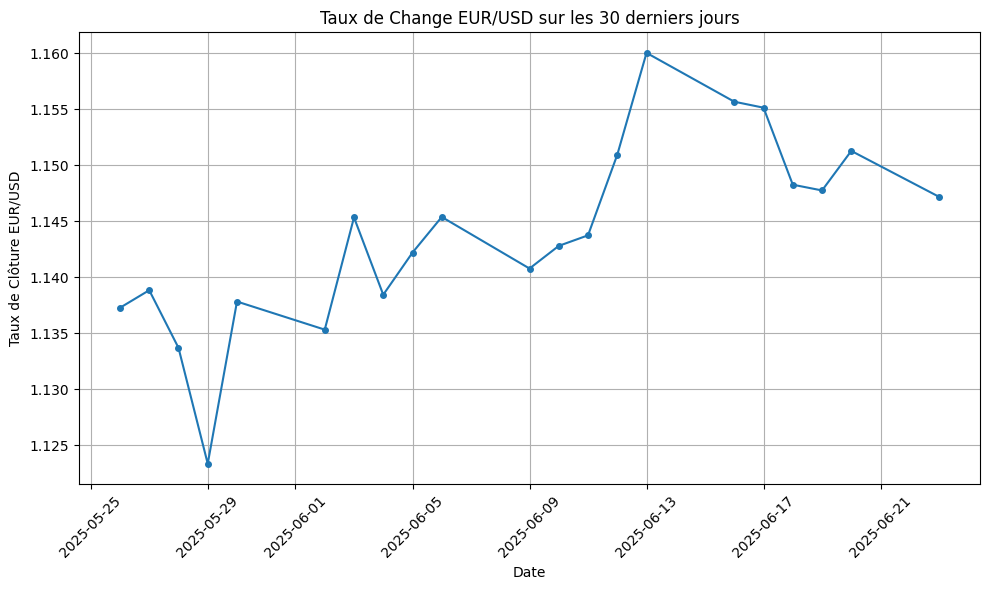


--- Fin de l'analyse ---


In [2]:
# simple_analyse_taux_change.py

# 1. Préparation - Importation des bibliothèques nécessaires
#    pip install yfinance pandas matplotlib pytest

# Importer les bibliothèques
import yfinance as yf          # Pour télécharger les données financières
import pandas as pd            # Pour travailler avec les données tabulaires (DataFrames)
from datetime import datetime, timedelta # Pour calculer les dates
import os                      # Pour vérifier si un fichier existe
import matplotlib.pyplot as plt # Pour créer des graphiques

# Nom du fichier CSV où les données seront sauvegardées
CSV_FILENAME = 'taux_change_eur_usd_simple.csv'

print(f"--- Début de l'analyse du taux de change EUR/USD ---")

# 2. Récupérer les données du taux de change pour les 30 derniers jours
try:
    end_date = datetime.today()
    # Calcule la date de début 30 jours avant la date de fin
    start_date = end_date - timedelta(days=30)

    print(f"Récupération des données pour EUR/USD=X du {start_date.strftime('%Y-%m-%d')} au {end_date.strftime('%Y-%m-%d')}...")

    # Télécharge les données historiques
    # interval='1d' pour avoir des données journalières
    # Ajout d'un jour à end_date car yfinance exclut la date de fin
    data = yf.Ticker("EURUSD=X").history(start=start_date, end=end_date + timedelta(days=1), interval='1d')

    if data.empty:
        print("Aucune donnée récupérée. Vérifiez le ticker ou la connexion internet.")
        # On sort du script si pas de données
        exit()

    print(f"Données récupérées avec succès ({len(data)} jours).")

    # 3. Enregistrer les données dans un fichier CSV
    # index=True inclut la colonne des dates dans le fichier CSV
    data.to_csv(CSV_FILENAME, index=True)
    print(f"Données enregistrées dans {CSV_FILENAME}")

except Exception as e:
    print(f"Erreur lors de la récupération ou de l'enregistrement des données : {e}")
    exit() # Quitte si une erreur survient ici

# 4. Charger les données depuis le fichier CSV
print(f"\nChargement des données depuis {CSV_FILENAME}...")
if not os.path.exists(CSV_FILENAME):
    print(f"Erreur : Le fichier {CSV_FILENAME} n'a pas été trouvé.")
    exit() # Quitte si le fichier n'existe pas

try:
    # Charge les données depuis le CSV
    # index_col=0 dit que la première colonne est l'index (les dates)
    # parse_dates=True convertit l'index en vrais objets dates
    loaded_data = pd.read_csv(CSV_FILENAME, index_col=0, parse_dates=True)

    if loaded_data.empty:
         print(f"Erreur: Le fichier {CSV_FILENAME} est vide après chargement.")
         exit()

    print("Données chargées avec succès.")

except Exception as e:
    print(f"Erreur lors du chargement des données depuis le CSV : {e}")
    exit() # Quitte si une erreur survient ici

# --- Afficher un extrait des données brutes (Tableau 1 simple) ---
print("\n--- Extrait des Données Brutes ---")
# Affiche les premières lignes du DataFrame chargé
print(loaded_data.head().to_markdown()) # Utilise to_markdown pour un affichage plus propre
print("...")
# Affiche les dernières lignes du DataFrame chargé
print(loaded_data.tail().to_markdown())


# 5. Analyser la série temporelle
print("\n--- Analyse des Données ---")

# Utiliser la colonne 'Close' pour l'analyse du taux
close_prices = loaded_data['Close']

# a. Moyenne et écart-type
mean_rate = close_prices.mean()
std_dev = close_prices.std() # Peut être NaN si moins de 2 jours de données

# b. Dates des maximums/minimums
min_rate = close_prices.min()
date_min = close_prices.idxmin() # Obtient l'index (la date) de la valeur minimale
max_rate = close_prices.max()
date_max = close_prices.idxmax() # Obtient l'index (la date) de la valeur maximale

# c. Variation journalière
# Calcule la différence entre le prix de clôture d'aujourd'hui et celui d'hier
# .dropna() enlève la première valeur qui est NaN (pas de jour précédent)
daily_changes = close_prices.diff().dropna()

# d. Jours de hausse ou de baisse
# Compte les jours où la variation est positive (hausse) ou négative (baisse)
rising_days_count = (daily_changes > 0).sum()
falling_days_count = (daily_changes < 0).sum()
# Les jours où la variation est nulle ne sont comptés ni en hausse ni en baisse


# --- Afficher le rapport d'analyse (Tableau 2 simple) ---
print("\n--- Rapport d'Analyse du Taux EUR/USD ---")
# Formatage pour un affichage type tableau/résumé
print("-" * 40)
print(f"{'Indicateur':<25} | {'Valeur'}") # En-têtes alignés
print("-" * 40)
print(f"{'Moyenne Taux Clôture':<25} | {mean_rate:.4f}")
# Afficher l'écart-type seulement si calculé
print(f"{'Écart-type Taux Clôture':<25} | {std_dev:.4f}" if not pd.isna(std_dev) else f"{'Écart-type':<25} | {'N/A (moins de 2 jours)'}")
print(f"{'Taux Minimum':<25} | {min_rate:.4f}")
print(f"{'Date Minimum':<25} | {date_min.strftime('%Y-%m-%d')}")
print(f"{'Taux Maximum':<25} | {max_rate:.4f}")
print(f"{'Date Maximum':<25} | {date_max.strftime('%Y-%m-%d')}")
print(f"{'Nombre de jours de hausse':<25} | {rising_days_count}")
print(f"{'Nombre de jours de baisse':<25} | {falling_days_count}")
print("-" * 40)

# Afficher quelques variations journalières
print("\n--- Exemples de Variations Journalières ---")
if not daily_changes.empty:
    # Créer un petit DataFrame pour afficher les variations avec les dates
    changes_df = daily_changes.reset_index()
    changes_df.columns = ['Date', 'Variation']
    # Formater la colonne Variation pour afficher le signe
    changes_df['Variation'] = changes_df['Variation'].apply(lambda x: f"{x:+.4f}")

    print(changes_df.head().to_markdown(index=False))
    if len(changes_df) > 10:
        print("...")
        print(changes_df.tail().to_markdown(index=False))
    elif len(changes_df) > 5:
         print(changes_df.tail(len(changes_df) - 5).to_markdown(index=False))
else:
    print("Pas de variations journalières à afficher (moins de 2 jours).")

# --- Générer le graphique des taux de clôture ---
print("\nGénération du graphique...")

try:
    plt.figure(figsize=(10, 6)) # Crée une figure et des axes de taille spécifiée
    plt.plot(close_prices.index, close_prices.values, marker='o', linestyle='-', markersize=4) # Trace le taux de clôture

    # Ajouter des titres et labels
    plt.title('Taux de Change EUR/USD sur les 30 derniers jours')
    plt.xlabel('Date')
    plt.ylabel('Taux de Clôture EUR/USD')
    plt.grid(True) # Ajouter une grille

    # Améliorer la lisibilité des dates sur l'axe x
    plt.xticks(rotation=45) # Rotation des labels de l'axe x
    plt.tight_layout() # Ajuste la mise en page pour éviter que les labels ne se chevauchent

    # Afficher le graphique
    print("Affichage du graphique...")
    plt.show()

except Exception as e:
    print(f"Erreur lors de la génération ou de l'affichage du graphique : {e}")


print("\n--- Fin de l'analyse ---")
